In [108]:
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import xarray as xr
import rioxarray as rxr
import codebase

Notes:
- Neches is a triburtary of Sabine river. Number of dams is one more than the number of basins.

In [2]:
grdc_dir = "/global/scratch/users/ann_scheliga/aux_dam_datasets/GRDC_CRB/"
res_dir = "/global/scratch/users/ann_scheliga/CYGNSS_daily/time_series/"

In [3]:
res_shp = codebase.load_data.load_GRanD()
subregions_meta = gpd.read_file(grdc_dir + 'subregions.geojson')

In [9]:
site_series = pd.read_json('../dam_basin_pair.json',typ='series')

In [ ]:
site_stations = gpd.read_file(grdc_dir+'site_stationbasins.geojson')
site_stations.set_index(site_stations['grdc_no'].astype(int),inplace=True)

In [104]:
dam_names = [item.replace('_',' ') for item in list(site_series)]
dam_shps = res_shp[res_shp['DAM_NAME'].str.lower().isin(dam_names)]

## Create and write synthesized station basin dataset
from site_series variable (```dam_basin_pair.json``` file)

In [ ]:
station_fn_list = [fn for fn in os.listdir(grdc_dir) if 'stationbasins' in fn]
site_stations = gpd.GeoDataFrame()
for fn in station_fn_list:
    stations_meta = gpd.read_file(grdc_dir + fn)
    stations_meta.set_index(stations_meta['grdc_no'].astype(int),inplace=True)
    stations = stations_meta[stations_meta.index.isin(site_series.index)]
    site_stations = pd.concat([site_stations, stations])
# site_stations.to_file(grdc_dir+'site_stationbasins.geojson',driver='GeoJSON',index=False)

## Create global map

In [106]:
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

/tmp/ipykernel_2461972/3912264495.py:1: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))


In [128]:
site_stations['lat_lon'] = gpd.points_from_xy(y =site_stations['lat_org'], x =  site_stations['long_org'])
stations_points = site_stations.set_geometry('lat_lon', crs = "EPSG:4326")

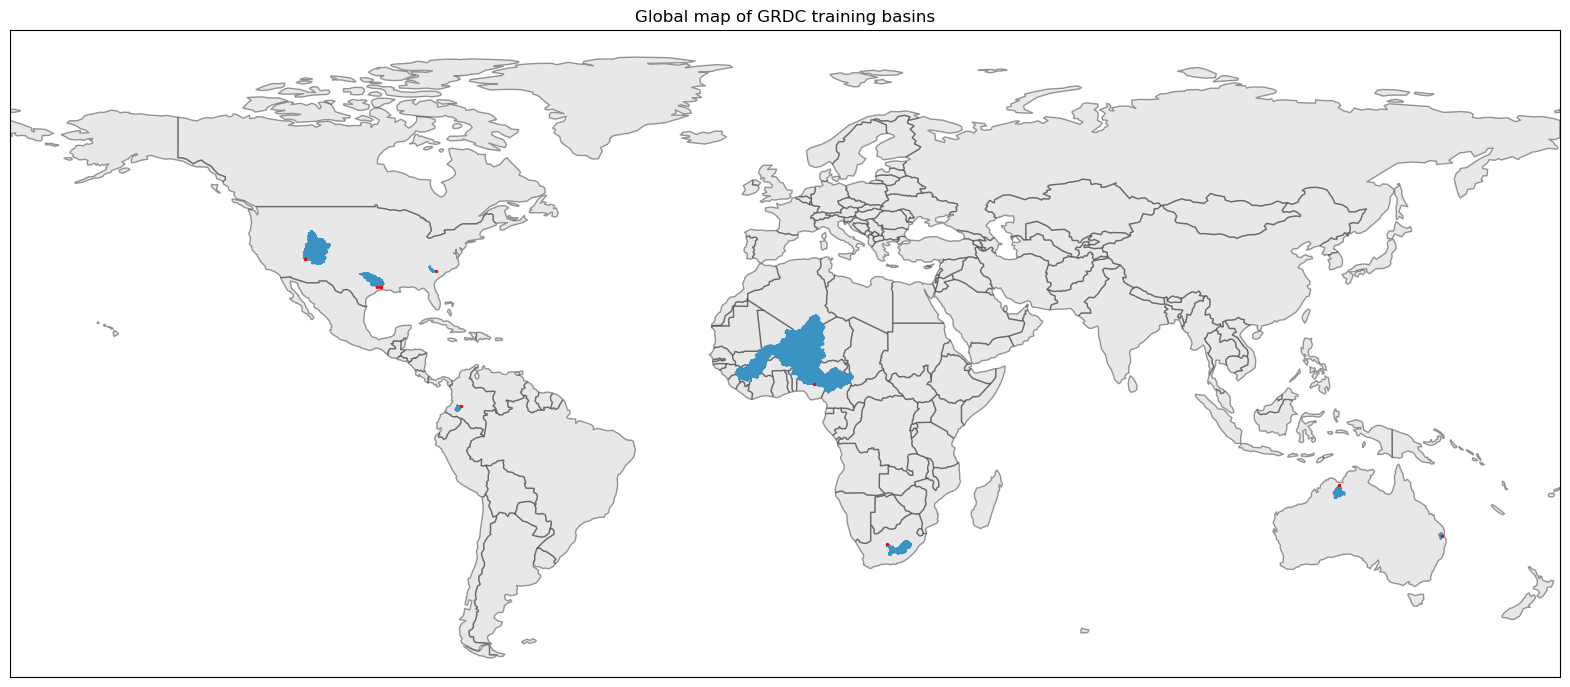

<Figure size 640x480 with 0 Axes>

In [ ]:
fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot()
lightblue = np.array([58,147,195])/255

# plot a basic map of the world
world.plot(
    ax = ax,
    color="lightgray",
    edgecolor=[0.2,0.2,0.2],
    alpha=0.5
)

# turn off axis ticks
ax.set_xticks([])
ax.set_yticks([])

ax.set_xlim([-180,180])
ax.set_ylim([-60,90])

site_stations.plot(ax=ax,color=lightblue,edgecolor=lightblue,linewidth=0.5)
stations_points.plot(ax=ax,color='red',edgecolor='red',markersize=2)

# set the plot title
plt.title("Global map of GRDC training basins")
plt.show()
# plt.savefig('./global_grdc_basin_map.png')

<Axes: >

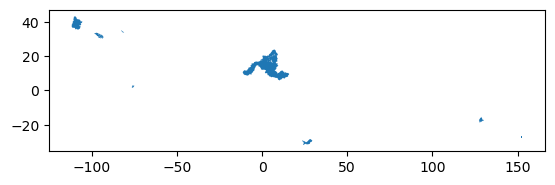

<Axes: >

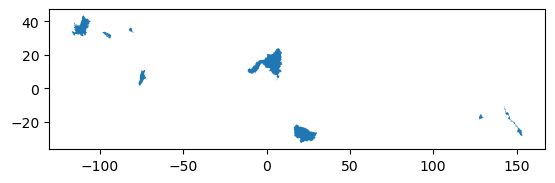

In [70]:
site_subregions.plot()

In [ ]:

test_fn = station_fn_list[0]

In [86]:
stations_meta.index

Index([5608090, 5608091, 5608093, 5608095, 5608096, 5608098, 5708094], dtype='int64', name='grdc_no')

In [87]:
site_series.index

Index([4152450, 1834101, 3103450, 1159302, 5608096, 5101500, 4150600, 4150680,
       4150700, 4148535],
      dtype='int64')

In [ ]:
site_stations = stations_meta[stations_meta.index.isin(site_series.index)]

In [91]:
site_stations

,grdc_no,river,station,area,altitude,lat_org,long_org,lat_pp,long_pp,dist_km,area_calc,quality,type,comment,source,geometry
grdc_no,,,,,,,,,,,,,,,,
5608096,5608096.0,ORD RIVER,TARRARA BAR,51028.0,28.35,-15.5696,128.693,-15.5729,128.6937,0.4,51205.5,High,Automatic,Area difference <= 5% and distance <= 5 km,hydrosheds,"POLYGON ((128.69580 -15.43330, 128.71670 -15.4..."
